In [2]:
import pandas as pd
import numpy as np


In [3]:
solubility =pd.read_csv('../data/delaney-processed.csv')

as the file solubility is in model not in jupyter folder so, solubility= pd.read_csv('data/delaney-processed.csv') will not work because the  csv file is in data.

In [4]:
solubility

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.770,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.300,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.060,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.870,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.330,c1ccsc1
...,...,...,...,...,...,...,...,...,...,...
1123,halothane,-2.608,1,197.381,0,0,0,0.00,-1.710,FC(F)(F)C(Cl)Br
1124,Oxamyl,-0.908,1,219.266,1,0,1,71.00,0.106,CNC(=O)ON=C(SC)C(=O)N(C)C
1125,Thiometon,-3.323,1,246.359,0,0,7,18.46,-3.091,CCSCCSP(=S)(OC)OC
1126,2-Methylbutane,-2.245,1,72.151,0,0,1,0.00,-3.180,CCC(C)C


In [5]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(solubility, test_size=0.2, random_state=42)

In [6]:
X = train_set.drop(['Compound ID', 'smiles', 'measured log solubility in mols per litre', 'ESOL predicted log solubility in mols per litre'], axis=1)

doubt - why axis = 1?

In [7]:
Y_tr = train_set['measured log solubility in mols per litre']

In [8]:
X

,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area
876,1,122.167,1,1,0,20.23
712,1,74.123,0,0,2,9.23
554,1,207.070,0,2,0,0.00
688,1,213.310,0,1,3,45.15
780,2,252.316,0,5,0,0.00
...,...,...,...,...,...,...
121,1,114.232,0,0,2,0.00
1044,1,110.181,1,1,0,0.00
1095,1,288.255,4,3,1,107.22
860,1,137.138,0,1,1,39.19


In [9]:
Y_tr

876    -1.400
712    -0.390
554    -4.400
688    -2.676
780    -8.000
        ...  
121    -4.800
1044   -2.120
1095   -3.620
860    -0.460
1126   -3.180
Name: measured log solubility in mols per litre, Length: 902, dtype: float64

<Axes: xlabel='Molecular Weight', ylabel='measured log solubility in mols per litre'>

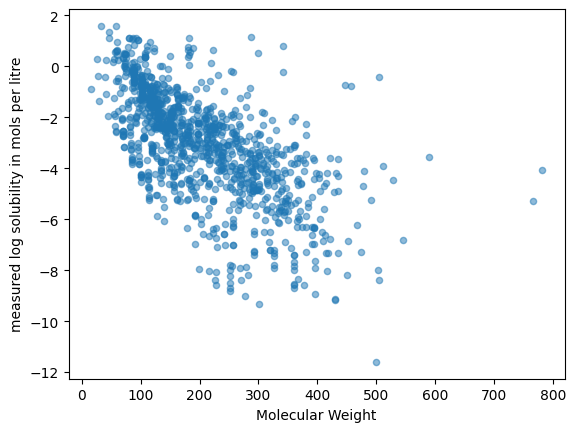

In [10]:
solubility.plot(kind= 'scatter', x= 'Molecular Weight', y= 'measured log solubility in mols per litre' , alpha = 0.5)

<Axes: xlabel='Minimum Degree', ylabel='measured log solubility in mols per litre'>

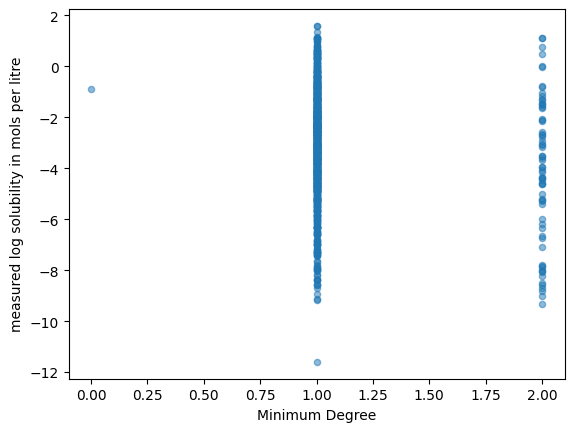

In [11]:
solubility.plot(kind= 'scatter', x= 'Minimum Degree', y= 'measured log solubility in mols per litre' , alpha = 0.5)

<Axes: xlabel='Number of H-Bond Donors', ylabel='measured log solubility in mols per litre'>

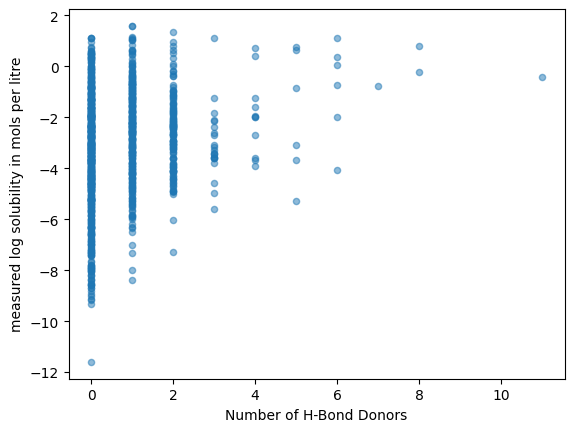

In [12]:
solubility.plot(kind= 'scatter', x= 'Number of H-Bond Donors', y= 'measured log solubility in mols per litre' , alpha = 0.5)

<Axes: xlabel='Number of Rings', ylabel='measured log solubility in mols per litre'>

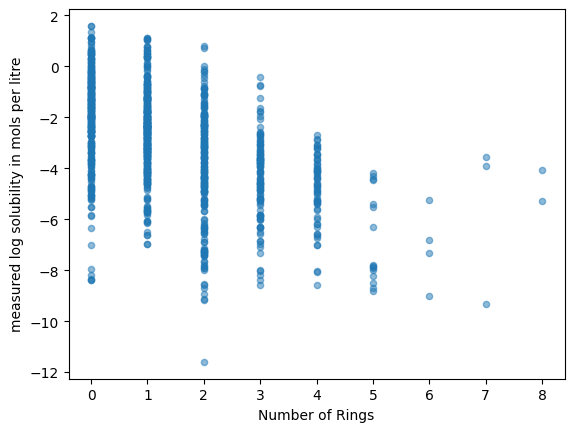

In [13]:
solubility.plot(kind= 'scatter', x= 'Number of Rings', y= 'measured log solubility in mols per litre' , alpha = 0.5)

<Axes: xlabel='Number of Rotatable Bonds', ylabel='measured log solubility in mols per litre'>

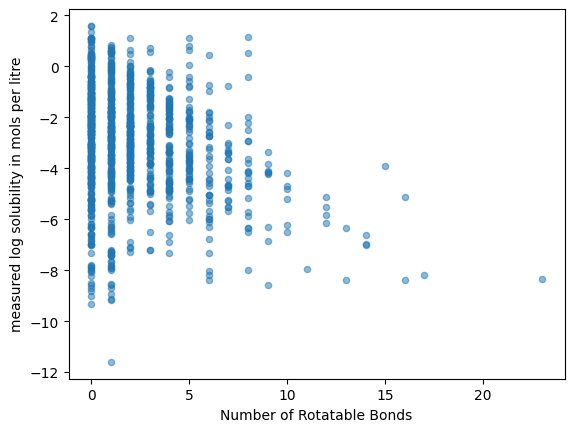

In [14]:
solubility.plot(kind= 'scatter', x= 'Number of Rotatable Bonds', y= 'measured log solubility in mols per litre' , alpha = 0.5)

<Axes: xlabel='Polar Surface Area', ylabel='measured log solubility in mols per litre'>

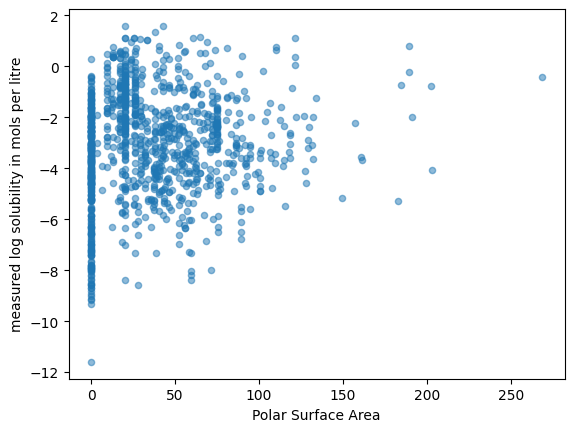

In [15]:
solubility.plot(kind= 'scatter', x= 'Polar Surface Area', y= 'measured log solubility in mols per litre' , alpha = 0.5)

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    (  'imputer', SimpleImputer(strategy="median")),
       # ('attribs_adder',CombinedAttributesAdder()),
        ('std_scalar', StandardScaler()),
    ])
X_tr = num_pipeline.fit_transform(X)

In [17]:
X_tr

array([[-0.22936656, -0.7942196 ,  0.2796872 , -0.28711034, -0.83999025,
        -0.42153291],
       [-0.22936656, -1.25780183, -0.65467521, -1.05104406, -0.07927619,
        -0.73437391],
       [-0.22936656,  0.02501948, -0.65467521,  0.47682337, -0.83999025,
        -0.99687595],
       ...,
       [-0.22936656,  0.80838313,  3.08277442,  1.24075709, -0.45963322,
         2.0524706 ],
       [-0.22936656, -0.64976265, -0.65467521, -0.28711034, -0.45963322,
         0.11769121],
       [-0.22936656, -1.27682989, -0.65467521, -1.05104406, -0.45963322,
        -0.99687595]], shape=(902, 6))

I am not using X_tr (standardized data) in this model, simply because the X (raw data) is giving better results.

In [18]:
print(pd.DataFrame(X_tr).duplicated().sum())

118


In [19]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_tr, Y_tr)

LinearRegression()

In [20]:
some_data = X[:5]
some_labels = Y_tr[:5]
some_data_prepared = num_pipeline.transform(some_data)
print("Prediction:", lin_reg.predict(some_data_prepared))
print("labels:", list(some_labels))

Prediction: [-1.86449623 -1.56412724 -4.1481884  -2.87887888 -6.2517054 ]
labels: [-1.4, -0.39, -4.4, -2.676, -8.0]


In [21]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lin_reg, X_tr, Y_tr,
                         scoring="neg_mean_squared_error", cv=10)
linreg_rmse_score = np.sqrt(-scores)

In [22]:
def display_scores(scores):
    print("scores:", scores)
    print("mean", scores.mean())
    print("std", scores.std())


display_scores(linreg_rmse_score)

scores: [1.07333378 1.15960975 1.07505294 1.19265423 1.13927164 1.10637025
 1.22081386 1.38196046 1.23454263 1.21655502]
mean 1.1800164560926472
std 0.08764277825072014


In [23]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_tr,Y_tr)

DecisionTreeRegressor()

In [24]:
some_data = X[:5]
some_labels = Y_tr[:5]
some_data_prepared = num_pipeline.transform(some_data)
print("Prediction:", tree_reg.predict(some_data_prepared))
print("labels:", list(some_labels))

Prediction: [-1.29333333 -0.24       -4.4        -2.676      -8.3495    ]
labels: [-1.4, -0.39, -4.4, -2.676, -8.0]


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, X_tr, Y_tr,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_score = np.sqrt(-scores)

In [26]:
def display_scores(scores):
    print("scores:", scores)
    print("mean", scores.mean())
    print("std", scores.std())


display_scores(tree_rmse_score)

scores: [0.92291837 1.08429379 1.03439196 1.4035079  0.95034094 1.23307744
 1.25822402 1.14759796 1.03739566 1.114454  ]
mean 1.1186202052892718
std 0.14003392372939105


In [39]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(X_tr, Y_tr)
model= forest_reg

In [42]:
some_data = X[:5]
some_labels = Y_tr[:5]
some_data_prepared = num_pipeline.transform(some_data)
print("Prediction:", forest_reg.predict(some_data_prepared))
print("labels:", list(some_labels))

Prediction: [-1.25896702 -0.2344     -4.50535571 -2.74201    -8.18959617]
labels: [-1.4, -0.39, -4.4, -2.676, -8.0]


In [43]:
print(model.predict(some_data_prepared))

[-1.25896702 -0.2344     -4.50535571 -2.74201    -8.18959617]


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(forest_reg, X_tr , Y_tr ,
                         scoring="neg_mean_squared_error", cv=10)
forest_rmse_score = np.sqrt(-scores)

In [30]:
def display_scores(scores):
    print("scores:", scores)
    print("mean", scores.mean())
    print("std", scores.std())


display_scores(forest_rmse_score)

scores: [0.62802988 0.82833185 0.81172022 0.94623493 0.69865941 0.95641407
 1.00156578 0.94943058 0.88772313 0.97326878]
mean 0.8681378631762116
std 0.118693599995703


ok so random forest is performing better than other models, so we can fine tune this to make it better.

In [31]:
from sklearn.model_selection import GridSearchCV

# We limit the number of combinations to keep it fast
param_grid = [
    {
        'n_estimators': [50, 100],      # Fewer trees = much faster
        'max_features': [2, 3, 4],      # Look at fewer features at each split
        'bootstrap': [True]             # Standard setting for Random Forest
    }
]

forest_reg = RandomForestRegressor(random_state=42)

# cv=3 means it only runs 3 times per combination instead of 5 or 10
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1)  # Uses all your CPU cores to speed up

grid_search.fit(X_tr, Y_tr)

print("Best settings:", grid_search.best_params_)

Best settings: {'bootstrap': True, 'max_features': 2, 'n_estimators': 100}


In [32]:
final_model= grid_search.best_estimator_

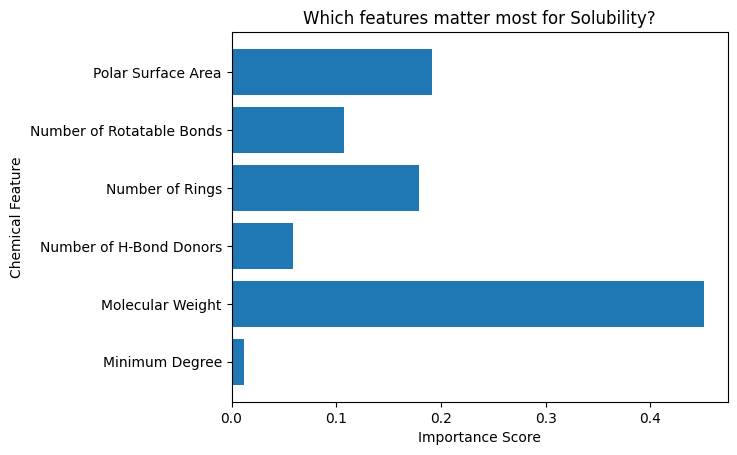

In [33]:
import matplotlib.pyplot as plt

# 1. Get the importance values from your best model
importances = grid_search.best_estimator_.feature_importances_

# 2. Match them with your column names
# Replace 'housing_num' with the dataframe containing your features
feature_names = list(X.columns)
# Note: If you added extra attributes, add them to the list here too

# 3. Sort and plot
plt.barh(feature_names, importances)
plt.xlabel("Importance Score")
plt.ylabel("Chemical Feature")
plt.title("Which features matter most for Solubility?")
plt.show()

clearly, mol weight influence solubility the most followed by polar surface area.

In [34]:
final_model.predict(X_tr)
final_predictions= final_model.predict(X_tr)

In [35]:
from sklearn.metrics import mean_squared_error
rmse= np.sqrt(mean_squared_error(Y_tr,final_predictions))
print("Final RMSE:", rmse)

Final RMSE: 0.33051473955692584


now uploading both model and pipeline.

In [44]:
import joblib
export_data = {
    'model': forest_reg,
    'pipeline': num_pipeline
}

joblib.dump(export_data, 'solubility_model_package.joblib')
print("Model and Pipeline saved successfully!")

Model and Pipeline saved successfully!


In [51]:
import pandas as pd
import joblib

loaded_package = joblib.load('solubility_model_package.joblib')
model = loaded_package['model']
pipeline = loaded_package['pipeline']
new_data = pd.DataFrame([[1, 480.1, 2, 0, 3, 0.5]],
    columns=[
        'Minimum Degree',
        'Molecular Weight',
        'Number of H-Bond Donors',
        'Number of Rings',
        'Number of Rotatable Bonds',
        'Polar Surface Area'
    ])


data_prepared = pipeline.transform(new_data)
prediction = model.predict(data_prepared)

print(f"Predicted LogS: {prediction[0]:.3f}")

Predicted LogS: -5.843
